In [1]:
import os, random, shutil, time, json, difflib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.preprocessing.image import (ImageDataGenerator,
                                                  load_img, img_to_array, array_to_img)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

IMG_SIZE     = (224, 224)
BATCH_SIZE   = 32
TARGET_AUG   = 500        # jumlah file per kelas untuk augmentasi offline
TEST_RATIO   = 0.2        # 20% test
VAL_RATIO    = 0.25       # 25% dari sisa = 20% total → 60/20/20

AUG_TRANSFORMS = dict(rotation_range=20, width_shift_range=0.2,
                      height_shift_range=0.2, shear_range=0.2,
                      zoom_range=0.2, horizontal_flip=True, fill_mode='nearest')

print("TensorFlow:", tf.__version__)
print("GPU       :", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU       : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
SRC = '/kaggle/input/datasets/vikaschauhan734/120-dog-breed-image-classification/images'
assert os.path.isdir(SRC), f"Path tidak ditemukan: {SRC}"
print("✅ SRC:", SRC, "| jumlah folder:", len(os.listdir(SRC)))

✅ SRC: /kaggle/input/datasets/vikaschauhan734/120-dog-breed-image-classification/images | jumlah folder: 120


In [3]:
selected_breeds_raw = [
    'Siberian_husky', 'malamute', 'golden_retriever', 'Labrador_retriever',
    'beagle', 'German_shepherd', 'boxer', 'pug', 'French_bulldog',
    'Chihuahua', 'Samoyed', 'Doberman', 'Rottweiler',
    'cocker_spaniel', 'Shih-Tzu'
]

available = os.listdir(SRC)
lower_map = {d.lower(): d for d in available}
selected_breeds = []
for b in selected_breeds_raw:
    if b in available:               selected_breeds.append(b)
    elif b.lower() in lower_map:     selected_breeds.append(lower_map[b.lower()])
    else:
        print(f"❌ '{b}' tidak ada. Mirip:", difflib.get_close_matches(b, available, 3, 0.4))

assert len(selected_breeds) == 15, "Perbaiki nama ras dulu!"
for b in selected_breeds:
    print(f"{b:25s} {len(os.listdir(os.path.join(SRC,b))):4d} citra")

Siberian_husky             192 citra
malamute                   178 citra
golden_retriever           150 citra
Labrador_retriever         171 citra
beagle                     195 citra
German_shepherd            152 citra
boxer                      151 citra
pug                        200 citra
French_bulldog             159 citra
Chihuahua                  152 citra
Samoyed                    218 citra
Doberman                   150 citra
Rottweiler                 152 citra
cocker_spaniel             159 citra
Shih-Tzu                   214 citra


In [4]:
TRAINVAL_PATH = '/kaggle/working/dataset_trainval'
TEST_PATH     = '/kaggle/working/dataset_test'

for p in [TRAINVAL_PATH, TEST_PATH]:
    if os.path.exists(p): shutil.rmtree(p)
    os.makedirs(p)

random.seed(SEED)
rows = []
for breed in selected_breeds:
    folder = breed.split('-', 1)[1].lower() if '-' in breed else breed.lower()
    src_dir = os.path.join(SRC, breed)
    imgs = sorted(os.listdir(src_dir)); random.shuffle(imgs)
    n_test = int(len(imgs) * TEST_RATIO)
    for subset, dest in [(imgs[:n_test], TEST_PATH), (imgs[n_test:], TRAINVAL_PATH)]:
        os.makedirs(os.path.join(dest, folder), exist_ok=True)
        for im in subset:
            shutil.copy(os.path.join(src_dir, im), os.path.join(dest, folder, im))
    rows.append({'Ras': folder, 'Total': len(imgs),
                 'TrainVal': len(imgs)-n_test, 'Test': n_test})

df_split = pd.DataFrame(rows)
print(df_split.to_string(index=False))
print("TOTAL:", df_split['Total'].sum())
df_split.to_csv('/kaggle/working/distribusi_dataset.csv', index=False)

               Ras  Total  TrainVal  Test
    siberian_husky    192       154    38
          malamute    178       143    35
  golden_retriever    150       120    30
labrador_retriever    171       137    34
            beagle    195       156    39
   german_shepherd    152       122    30
             boxer    151       121    30
               pug    200       160    40
    french_bulldog    159       128    31
         chihuahua    152       122    30
           samoyed    218       175    43
          doberman    150       120    30
        rottweiler    152       122    30
    cocker_spaniel    159       128    31
               tzu    214       172    42
TOTAL: 2593


In [5]:
leak = False
for d in sorted(os.listdir(TEST_PATH)):
    a = set(os.listdir(os.path.join(TEST_PATH, d)))
    b = set(os.listdir(os.path.join(TRAINVAL_PATH, d)))
    if a & b:
        leak = True; print(f"❌ BOCOR di '{d}'")
assert not leak
print("✅ Tidak ada kebocoran test ↔ trainval")

✅ Tidak ada kebocoran test ↔ trainval


In [6]:
TRAIN_PATH  = '/kaggle/working/dataset_train'      # nanti diisi file augmentasi
VAL_PATH    = '/kaggle/working/dataset_val'
TRAIN_NOAUG = '/kaggle/working/dataset_train_asli' # salinan train tanpa augmentasi

for p in [TRAIN_PATH, VAL_PATH]:
    if os.path.exists(p): shutil.rmtree(p)
    os.makedirs(p)

random.seed(SEED)
for cls in sorted(os.listdir(TRAINVAL_PATH)):
    src_dir = os.path.join(TRAINVAL_PATH, cls)
    imgs = sorted(os.listdir(src_dir)); random.shuffle(imgs)
    n_val = int(len(imgs) * VAL_RATIO)
    for subset, dest in [(imgs[:n_val], VAL_PATH), (imgs[n_val:], TRAIN_PATH)]:
        os.makedirs(os.path.join(dest, cls), exist_ok=True)
        for im in subset:
            shutil.copy(os.path.join(src_dir, im), os.path.join(dest, cls, im))

if os.path.exists(TRAIN_NOAUG): shutil.rmtree(TRAIN_NOAUG)
shutil.copytree(TRAIN_PATH, TRAIN_NOAUG)

for cls in sorted(os.listdir(TRAIN_PATH)):
    print(f"{cls:22s} train={len(os.listdir(os.path.join(TRAIN_PATH,cls))):4d}  "
          f"val={len(os.listdir(os.path.join(VAL_PATH,cls))):3d}")

beagle                 train= 117  val= 39
boxer                  train=  91  val= 30
chihuahua              train=  92  val= 30
cocker_spaniel         train=  96  val= 32
doberman               train=  90  val= 30
french_bulldog         train=  96  val= 32
german_shepherd        train=  92  val= 30
golden_retriever       train=  90  val= 30
labrador_retriever     train= 103  val= 34
malamute               train= 108  val= 35
pug                    train= 120  val= 40
rottweiler             train=  92  val= 30
samoyed                train= 132  val= 43
siberian_husky         train= 116  val= 38
tzu                    train= 129  val= 43


In [7]:
aug_engine = ImageDataGenerator(**AUG_TRANSFORMS)
random.seed(SEED); np.random.seed(SEED)

for cls in sorted(os.listdir(TRAIN_PATH)):
    d = os.path.join(TRAIN_PATH, cls)
    orig = sorted([f for f in os.listdir(d) if not f.startswith('aug_')])
    need = TARGET_AUG - len(orig)
    for i in range(max(need, 0)):
        src = orig[i % len(orig)]                       # gilir merata semua citra asli
        arr = np.expand_dims(img_to_array(load_img(os.path.join(d, src))), 0)
        array_to_img(next(aug_engine.flow(arr, batch_size=1))[0]).save(
            os.path.join(d, f"aug_{i:04d}_{src}"))
    print(f"{cls:22s} {len(orig):3d} asli + {max(need,0):3d} augmentasi "
          f"= {len(os.listdir(d))}")

beagle                 117 asli + 383 augmentasi = 500
boxer                   91 asli + 409 augmentasi = 500
chihuahua               92 asli + 408 augmentasi = 500
cocker_spaniel          96 asli + 404 augmentasi = 500
doberman                90 asli + 410 augmentasi = 500
french_bulldog          96 asli + 404 augmentasi = 500
german_shepherd         92 asli + 408 augmentasi = 500
golden_retriever        90 asli + 410 augmentasi = 500
labrador_retriever     103 asli + 397 augmentasi = 500
malamute               108 asli + 392 augmentasi = 500
pug                    120 asli + 380 augmentasi = 500
rottweiler              92 asli + 408 augmentasi = 500
samoyed                132 asli + 368 augmentasi = 500
siberian_husky         116 asli + 384 augmentasi = 500
tzu                    129 asli + 371 augmentasi = 500


In [8]:
def make_gens(train_path, rescale, augment_runtime=False):
    """augment_runtime=True hanya untuk skenario pembanding real-time."""
    kw = {'rescale': rescale} if rescale else {}
    train_dg = ImageDataGenerator(**kw, **(AUG_TRANSFORMS if augment_runtime else {}))
    eval_dg  = ImageDataGenerator(**kw)     # val & test: polos, tanpa transformasi

    tr = train_dg.flow_from_directory(train_path, target_size=IMG_SIZE,
            batch_size=BATCH_SIZE, class_mode='categorical', seed=SEED, shuffle=True)
    va = eval_dg.flow_from_directory(VAL_PATH, target_size=IMG_SIZE,
            batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)
    te = eval_dg.flow_from_directory(TEST_PATH, target_size=IMG_SIZE,
            batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)
    return tr, va, te

# ---- Generator MODEL UTAMA (offline: data sudah teraugmentasi di disk) ----
print("--- UTAMA MobileNetV2 (rescale 1/255) ---")
train_mob, val_mob, test_mob = make_gens(TRAIN_PATH, 1./255)
print("--- UTAMA EfficientNet-B0 (tanpa rescale) ---")
train_eff, val_eff, test_eff = make_gens(TRAIN_PATH, None)

class_labels = list(train_mob.class_indices.keys())
NUM_CLASSES  = len(class_labels)
print("Urutan kelas:", class_labels)

--- UTAMA MobileNetV2 (rescale 1/255) ---
Found 7500 images belonging to 15 classes.
Found 516 images belonging to 15 classes.
Found 513 images belonging to 15 classes.
--- UTAMA EfficientNet-B0 (tanpa rescale) ---
Found 7500 images belonging to 15 classes.
Found 516 images belonging to 15 classes.
Found 513 images belonging to 15 classes.
Urutan kelas: ['beagle', 'boxer', 'chihuahua', 'cocker_spaniel', 'doberman', 'french_bulldog', 'german_shepherd', 'golden_retriever', 'labrador_retriever', 'malamute', 'pug', 'rottweiler', 'samoyed', 'siberian_husky', 'tzu']


In [9]:
class TimeHistory(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):        self.times = []
    def on_epoch_begin(self, epoch, logs=None): self._t = time.time()
    def on_epoch_end(self, epoch, logs=None):   self.times.append(time.time()-self._t)

def build_model(arch, num_classes=None):
    num_classes = num_classes or NUM_CLASSES
    if arch == 'mobile':
        base = tf.keras.applications.MobileNetV2(
            input_shape=(224,224,3), include_top=False, weights='imagenet')
    else:
        base = tf.keras.applications.EfficientNetB0(
            input_shape=(224,224,3), include_top=False, weights='imagenet')
    base.trainable = False
    model = tf.keras.Sequential([
        base,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(num_classes, activation='softmax')])
    model.build((None, 224, 224, 3))
    return model, base

def get_metrics():
    return ['accuracy',
            tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top_3_accuracy')]

def count_trainable(m):
    return int(sum(np.prod(v.shape) for v in m.trainable_weights))

In [10]:
def train_two_stage(arch, train_gen, val_gen, tag,
                    warmup_epochs=15, total_epochs=50, unfreeze_layers=30,
                    lr_warmup=1e-4, lr_finetune=1e-5,
                    class_weight=None, verbose=1):
    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)
    model, base = build_model(arch)

    # TAHAP 1 — pemanasan kepala
    base.trainable = False
    model.compile(optimizer=tf.keras.optimizers.Adam(lr_warmup),
                  loss='categorical_crossentropy', metrics=get_metrics())
    print(f"[{tag}] TAHAP 1 — trainable: {count_trainable(model):,}")
    t1 = TimeHistory()
    h1 = model.fit(train_gen, validation_data=val_gen, epochs=warmup_epochs,
                   class_weight=class_weight, callbacks=[t1], verbose=verbose)

    # TAHAP 2 — fine-tuning
    base.trainable = True
    for layer in base.layers[:-unfreeze_layers]:
        layer.trainable = False
    for layer in base.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False

    model.compile(optimizer=tf.keras.optimizers.Adam(lr_finetune),
                  loss='categorical_crossentropy', metrics=get_metrics())
    print(f"[{tag}] TAHAP 2 — trainable: {count_trainable(model):,}")

    es   = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
    ckpt = ModelCheckpoint(f'/kaggle/working/best_{tag}.keras',
                           monitor='val_loss', mode='min',
                           save_best_only=True, verbose=0)
    t2 = TimeHistory()
    h2 = model.fit(train_gen, validation_data=val_gen,
                   epochs=total_epochs, initial_epoch=warmup_epochs,
                   class_weight=class_weight, callbacks=[es, ckpt, t2],
                   verbose=verbose)

    hist = {k: h1.history[k] + h2.history.get(k, []) for k in h1.history}
    total = sum(t1.times) + sum(t2.times)
    print(f"[{tag}] Total waktu: {int(total//60)}m {int(total%60)}s")
    return model, hist, total

In [11]:
print("=== SMOKE TEST (1+2 epoch, data offline) ===")
_m,_h,_t = train_two_stage('mobile', train_mob, val_mob, 'smoketest',
                           warmup_epochs=1, total_epochs=3, verbose=1)
va = _h['val_accuracy']
print("val_accuracy:", [round(v,4) for v in va])
assert va[1] > va[0] - 0.15, "❌ Akurasi anjlok di tahap 2 — cek BN/lr!"
print("✅ Pipeline aman.")
del _m,_h,_t; tf.keras.backend.clear_session()

=== SMOKE TEST (1+2 epoch, data offline) ===


I0000 00:00:1785084235.737857      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1785084235.744406      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
[smoketest] TAHAP 1 — trainable: 19,215


2026-07-26 16:44:12.455710: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-26 16:44:12.593599: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1785084254.744659     115 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  9/235 ━━━━━━━━━━━━━━━━━━━━ 14s 65ms/step - accuracy: 0.0564 - loss: 3.1920 - top_3_accuracy: 0.1884

2026-07-26 16:44:23.843210: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-26 16:44:23.980489: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.2144 - loss: 2.4881 - top_3_accuracy: 0.4508

2026-07-26 16:44:52.977511: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-26 16:44:53.113964: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


235/235 ━━━━━━━━━━━━━━━━━━━━ 57s 171ms/step - accuracy: 0.3884 - loss: 1.9996 - top_3_accuracy: 0.6519 - val_accuracy: 0.7558 - val_loss: 1.1587 - val_top_3_accuracy: 0.9457
[smoketest] TAHAP 2 — trainable: 1,529,935
Epoch 2/3
235/235 ━━━━━━━━━━━━━━━━━━━━ 41s 125ms/step - accuracy: 0.8027 - loss: 0.6604 - top_3_accuracy: 0.9573 - val_accuracy: 0.8702 - val_loss: 0.4192 - val_top_3_accuracy: 0.9787
Epoch 3/3
235/235 ━━━━━━━━━━━━━━━━━━━━ 16s 68ms/step - accuracy: 0.8891 - loss: 0.3592 - top_3_accuracy: 0.9823 - val_accuracy: 0.8857 - val_loss: 0.3585 - val_top_3_accuracy: 0.9864
[smoketest] Total waktu: 1m 54s
val_accuracy: [0.7558, 0.8702, 0.8857]
✅ Pipeline aman.


In [12]:
model_mob, hist_mob, time_mob = train_two_stage(
    'mobile', train_mob, val_mob, tag='mobilenet')
json.dump(hist_mob, open('/kaggle/working/history_mobilenet.json','w'))

[mobilenet] TAHAP 1 — trainable: 19,215
Epoch 1/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 36s 119ms/step - accuracy: 0.3969 - loss: 1.9920 - top_3_accuracy: 0.6493 - val_accuracy: 0.7674 - val_loss: 1.1373 - val_top_3_accuracy: 0.9419
Epoch 2/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 15s 61ms/step - accuracy: 0.7624 - loss: 0.9377 - top_3_accuracy: 0.9443 - val_accuracy: 0.8585 - val_loss: 0.6651 - val_top_3_accuracy: 0.9729
Epoch 3/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 15s 62ms/step - accuracy: 0.8405 - loss: 0.6306 - top_3_accuracy: 0.9716 - val_accuracy: 0.8779 - val_loss: 0.5058 - val_top_3_accuracy: 0.9826
Epoch 4/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 15s 62ms/step - accuracy: 0.8701 - loss: 0.4890 - top_3_accuracy: 0.9776 - val_accuracy: 0.8876 - val_loss: 0.4346 - val_top_3_accuracy: 0.9845
Epoch 5/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 15s 63ms/step - accuracy: 0.8803 - loss: 0.4230 - top_3_accuracy: 0.9811 - val_accuracy: 0.8973 - val_loss: 0.3908 - val_top_3_accuracy: 0.9845
Epoch 6/15
235/235 ━━━━━━━━━━━━━━━━━━━━

In [13]:
model_eff, hist_eff, time_eff = train_two_stage(
    'eff', train_eff, val_eff, tag='efficientnet')
json.dump(hist_eff, open('/kaggle/working/history_efficientnet.json','w'))

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
[efficientnet] TAHAP 1 — trainable: 19,215
Epoch 1/15


2026-07-26 16:52:48.644609: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-26 16:52:48.788421: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-26 16:52:49.145384: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-26 16:52:49.287360: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-26 16:52:50.078966: E external/local_xla/xla/stream_

217/235 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.2896 - loss: 2.3546 - top_3_accuracy: 0.5265

2026-07-26 16:53:13.804330: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-26 16:53:13.943581: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-26 16:53:14.269091: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-26 16:53:14.410877: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-26 16:53:15.175222: E external/local_xla/xla/stream_

235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.3059 - loss: 2.3232 - top_3_accuracy: 0.5441

2026-07-26 16:53:33.512246: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-26 16:53:33.647544: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-26 16:53:33.969481: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-26 16:53:34.112181: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-26 16:53:34.253930: E external/local_xla/xla/stream_

235/235 ━━━━━━━━━━━━━━━━━━━━ 63s 179ms/step - accuracy: 0.5121 - loss: 1.9237 - top_3_accuracy: 0.7624 - val_accuracy: 0.8295 - val_loss: 1.1940 - val_top_3_accuracy: 0.9864
Epoch 2/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 14s 61ms/step - accuracy: 0.8467 - loss: 0.9443 - top_3_accuracy: 0.9811 - val_accuracy: 0.8953 - val_loss: 0.6501 - val_top_3_accuracy: 0.9884
Epoch 3/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 14s 61ms/step - accuracy: 0.8944 - loss: 0.5967 - top_3_accuracy: 0.9921 - val_accuracy: 0.9128 - val_loss: 0.4534 - val_top_3_accuracy: 0.9884
Epoch 4/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 14s 61ms/step - accuracy: 0.9164 - loss: 0.4428 - top_3_accuracy: 0.9931 - val_accuracy: 0.9225 - val_loss: 0.3622 - val_top_3_accuracy: 0.9903
Epoch 5/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 14s 61ms/step - accuracy: 0.9296 - loss: 0.3596 - top_3_accuracy: 0.9947 - val_accuracy: 0.9283 - val_loss: 0.3125 - val_top_3_accuracy: 0.9942
Epoch 6/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 14s 61ms/step - accuracy: 0.9333 - loss: 0.3082 - 

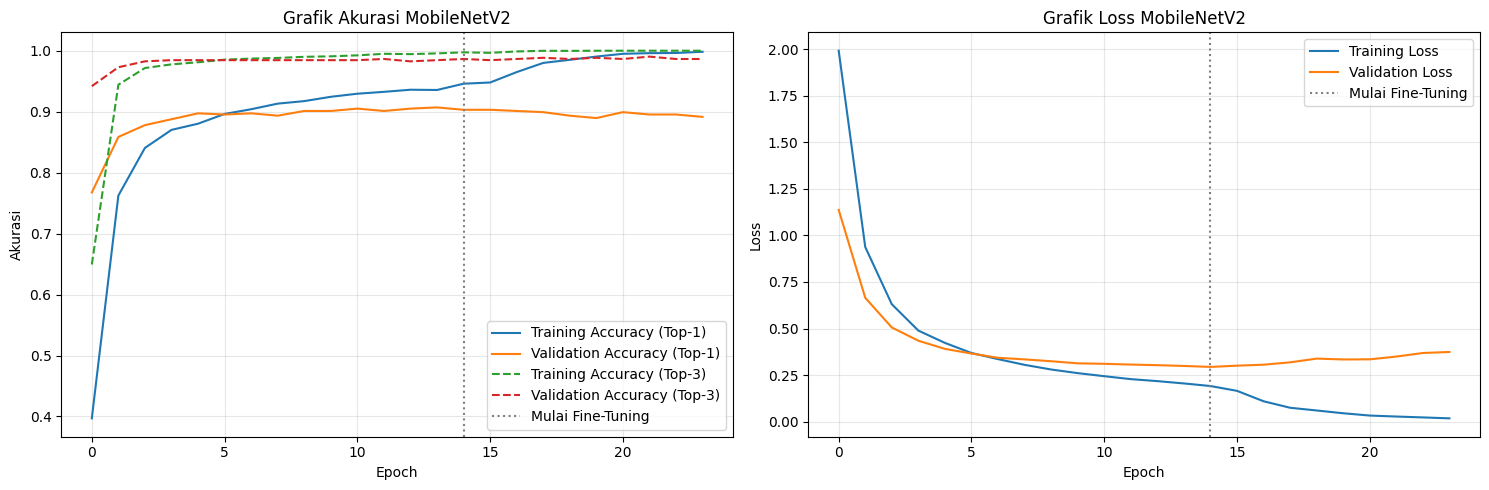

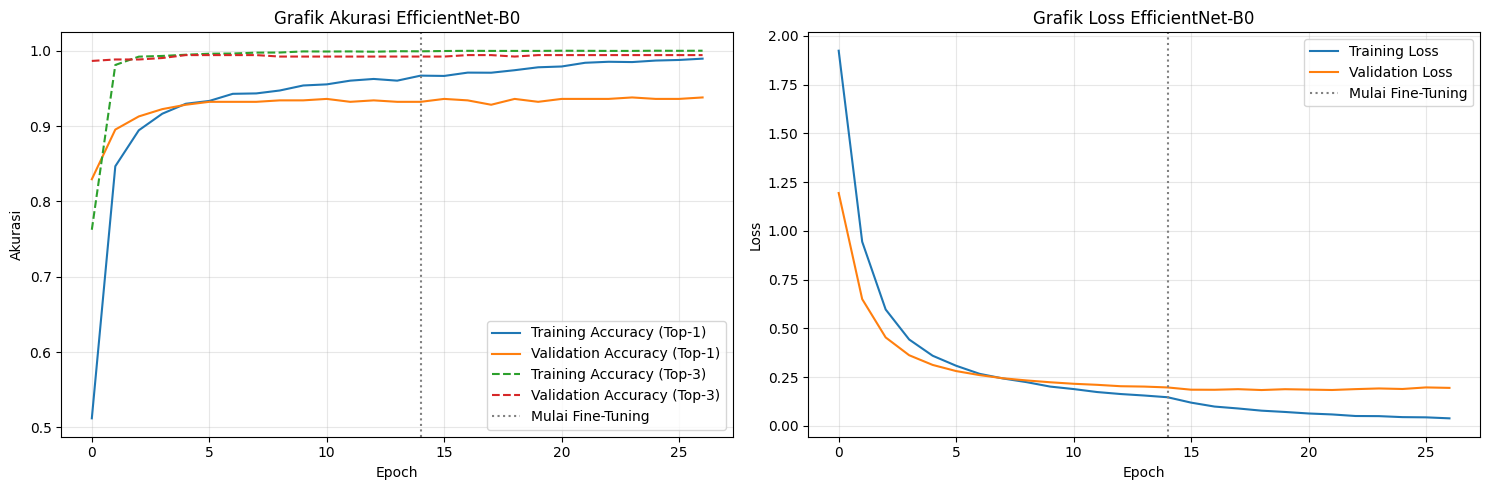

In [14]:
def plot_history(hist, title, warmup, fname):
    fig, ax = plt.subplots(1, 2, figsize=(15,5))
    ax[0].plot(hist['accuracy'],            label='Training Accuracy (Top-1)')
    ax[0].plot(hist['val_accuracy'],        label='Validation Accuracy (Top-1)')
    ax[0].plot(hist['top_3_accuracy'],'--', label='Training Accuracy (Top-3)')
    ax[0].plot(hist['val_top_3_accuracy'],'--',label='Validation Accuracy (Top-3)')
    ax[0].axvline(warmup-1, color='gray', ls=':', label='Mulai Fine-Tuning')
    ax[0].set_title(f'Grafik Akurasi {title}'); ax[0].set_xlabel('Epoch')
    ax[0].set_ylabel('Akurasi'); ax[0].legend(); ax[0].grid(alpha=.3)
    ax[1].plot(hist['loss'],     label='Training Loss')
    ax[1].plot(hist['val_loss'], label='Validation Loss')
    ax[1].axvline(warmup-1, color='gray', ls=':', label='Mulai Fine-Tuning')
    ax[1].set_title(f'Grafik Loss {title}'); ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('Loss'); ax[1].legend(); ax[1].grid(alpha=.3)
    plt.tight_layout(); plt.savefig(f'/kaggle/working/{fname}', dpi=150,
                                    bbox_inches='tight'); plt.show()

plot_history(hist_mob, 'MobileNetV2',     15, 'grafik_mobilenet.png')
plot_history(hist_eff, 'EfficientNet-B0', 15, 'grafik_efficientnet.png')

In [15]:
def evaluate_on_test(model, test_gen, tag):
    test_gen.reset()
    loss, acc, top3 = model.evaluate(test_gen, verbose=0)
    test_gen.reset()
    Y = model.predict(test_gen, verbose=0)
    y_pred = np.argmax(Y, axis=1); y_true = test_gen.classes

    print(f"\n===== TEST — {tag} =====")
    print(f"Top-1: {acc*100:.2f}%  Top-3: {top3*100:.2f}%  Loss: {loss:.4f}\n")
    rep = classification_report(y_true, y_pred, target_names=class_labels, digits=2)
    print(rep)
    with open(f'/kaggle/working/report_{tag}.txt','w') as f:
        f.write(f"Top-1 {acc*100:.2f}% | Top-3 {top3*100:.2f}% | Loss {loss:.4f}\n\n"+rep)

    cm = confusion_matrix(y_true, y_pred)
    pd.DataFrame(cm, index=class_labels, columns=class_labels)\
      .to_csv(f'/kaggle/working/cm_{tag}_berlabel.csv')
    return {'tag':tag,'acc':acc,'top3':top3,'loss':loss,
            'cm':cm,'y_true':y_true,'Y':Y,'y_pred':y_pred}

res_mob = evaluate_on_test(model_mob, test_mob, 'mobilenet')
res_eff = evaluate_on_test(model_eff, test_eff, 'efficientnet')

2026-07-26 17:00:58.801022: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-26 17:00:58.934617: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



===== TEST — mobilenet =====
Top-1: 90.45%  Top-3: 98.83%  Loss: 0.2612

                    precision    recall  f1-score   support

            beagle       0.95      0.95      0.95        39
             boxer       0.93      0.90      0.92        30
         chihuahua       0.84      0.90      0.87        30
    cocker_spaniel       0.88      0.97      0.92        31
          doberman       0.96      0.80      0.87        30
    french_bulldog       0.89      0.81      0.85        31
   german_shepherd       0.97      0.93      0.95        30
  golden_retriever       0.90      0.93      0.92        30
labrador_retriever       0.89      0.94      0.91        34
          malamute       0.87      0.74      0.80        35
               pug       0.90      0.90      0.90        40
        rottweiler       0.85      0.93      0.89        30
           samoyed       1.00      0.98      0.99        43
    siberian_husky       0.79      0.89      0.84        38
               tzu       

2026-07-26 17:01:15.109546: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-26 17:01:15.244269: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-26 17:01:15.982293: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-26 17:01:16.116976: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



===== TEST — efficientnet =====
Top-1: 94.54%  Top-3: 99.81%  Loss: 0.1513

                    precision    recall  f1-score   support

            beagle       0.97      0.97      0.97        39
             boxer       0.94      1.00      0.97        30
         chihuahua       0.94      0.97      0.95        30
    cocker_spaniel       0.97      0.97      0.97        31
          doberman       0.97      0.97      0.97        30
    french_bulldog       0.90      0.90      0.90        31
   german_shepherd       1.00      0.97      0.98        30
  golden_retriever       0.93      0.93      0.93        30
labrador_retriever       0.97      1.00      0.99        34
          malamute       0.85      0.80      0.82        35
               pug       1.00      0.93      0.96        40
        rottweiler       1.00      0.93      0.97        30
           samoyed       0.98      0.98      0.98        43
    siberian_husky       0.80      0.87      0.84        38
               tzu    

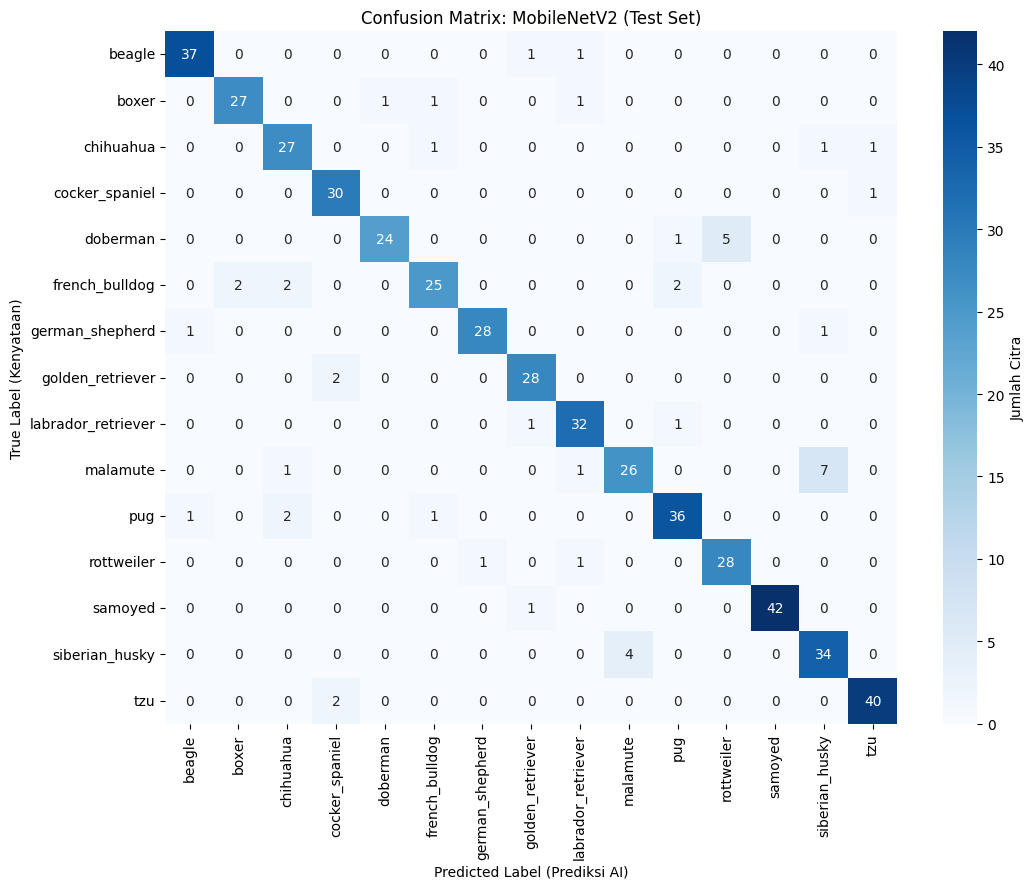

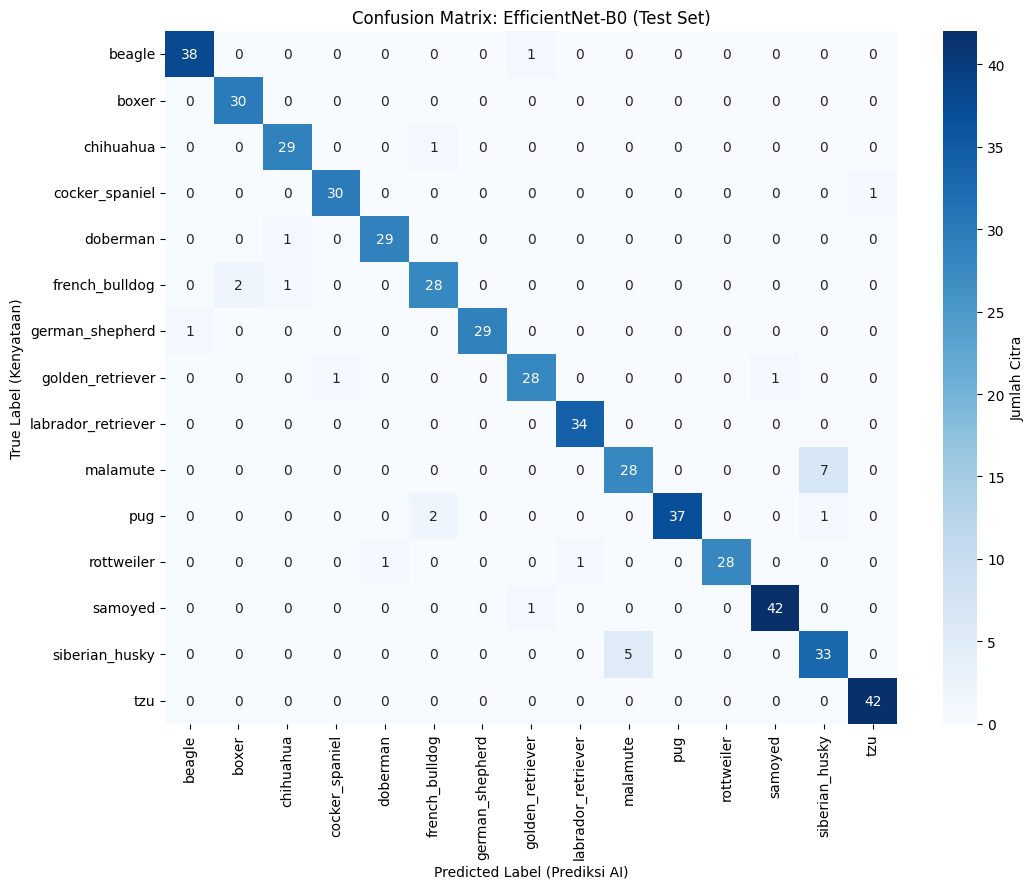

In [16]:
def plot_cm(cm, title, fname):
    plt.figure(figsize=(11,9))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels,
                cbar_kws={'label':'Jumlah Citra'})
    plt.title(f'Confusion Matrix: {title} (Test Set)')
    plt.ylabel('True Label (Kenyataan)'); plt.xlabel('Predicted Label (Prediksi AI)')
    plt.tight_layout(); plt.savefig(f'/kaggle/working/{fname}', dpi=150,
                                    bbox_inches='tight'); plt.show()

plot_cm(res_mob['cm'], 'MobileNetV2',     'cm_mobilenet.png')
plot_cm(res_eff['cm'], 'EfficientNet-B0', 'cm_efficientnet.png')

In [17]:
def fmt_time(s): return f"{int(s//60)}m {int(s%60)}s"

ep_mob = int(np.argmin(hist_mob['val_loss']))
ep_eff = int(np.argmin(hist_eff['val_loss']))
print(f"MobileNetV2    : epoch terbaik {ep_mob+1}, val_acc {hist_mob['val_accuracy'][ep_mob]*100:.2f}%")
print(f"EfficientNet-B0: epoch terbaik {ep_eff+1}, val_acc {hist_eff['val_accuracy'][ep_eff]*100:.2f}%")

tabel = pd.DataFrame({
    'Metrik Evaluasi': ['Validation Accuracy (Top-1)','Test Accuracy (Top-1)',
                        'Test Accuracy (Top-3)','Test Loss',
                        'Total Training Time','Jumlah Parameter'],
    'MobileNetV2': [f"{hist_mob['val_accuracy'][ep_mob]*100:.2f}%",
                    f"{res_mob['acc']*100:.2f}%", f"{res_mob['top3']*100:.2f}%",
                    f"{res_mob['loss']:.4f}", fmt_time(time_mob),
                    f"{model_mob.count_params():,}"],
    'EfficientNet-B0': [f"{hist_eff['val_accuracy'][ep_eff]*100:.2f}%",
                        f"{res_eff['acc']*100:.2f}%", f"{res_eff['top3']*100:.2f}%",
                        f"{res_eff['loss']:.4f}", fmt_time(time_eff),
                        f"{model_eff.count_params():,}"]})
print(tabel.to_string(index=False))
tabel.to_csv('/kaggle/working/tabel_perbandingan.csv', index=False)

MobileNetV2    : epoch terbaik 15, val_acc 90.31%
EfficientNet-B0: epoch terbaik 19, val_acc 93.60%
            Metrik Evaluasi MobileNetV2 EfficientNet-B0
Validation Accuracy (Top-1)      90.31%          93.60%
      Test Accuracy (Top-1)      90.45%          94.54%
      Test Accuracy (Top-3)      98.83%          99.81%
                  Test Loss      0.2612          0.1513
        Total Training Time      6m 37s          8m 11s
           Jumlah Parameter   2,277,199       4,068,786


In [18]:
model_mob.save_weights('/kaggle/working/mobile.weights.h5')
model_eff.save_weights('/kaggle/working/eff.weights.h5')
print("✅ Bobot model UTAMA (augmentasi offline) tersimpan.")

✅ Bobot model UTAMA (augmentasi offline) tersimpan.


In [19]:
def analisis_top3(res):
    Y, y_true, y_pred = res['Y'], res['y_true'], res['y_pred']
    top3 = np.argsort(Y, axis=1)[:, -3:][:, ::-1]
    salah = np.where(y_pred != y_true)[0]
    saved = [i for i in salah if y_true[i] in top3[i]]
    print(f"\n=== {res['tag']} ===")
    print(f"Salah di Top-1: {len(salah)} | Terselamatkan Top-3: {len(saved)} "
          f"| Tetap salah: {len(salah)-len(saved)}")
    for i in saved[:5]:
        p = [f"{class_labels[j]} {Y[i][j]*100:.1f}%" for j in top3[i]]
        print(f"  Asli: {class_labels[y_true[i]]:20s} → {p}")

analisis_top3(res_mob); analisis_top3(res_eff)


=== mobilenet ===
Salah di Top-1: 49 | Terselamatkan Top-3: 43 | Tetap salah: 6
  Asli: beagle               → ['golden_retriever 74.5%', 'labrador_retriever 15.8%', 'beagle 9.6%']
  Asli: beagle               → ['labrador_retriever 54.2%', 'beagle 22.6%', 'french_bulldog 17.1%']
  Asli: boxer                → ['french_bulldog 55.8%', 'pug 41.9%', 'boxer 1.8%']
  Asli: boxer                → ['doberman 73.4%', 'boxer 19.6%', 'beagle 4.8%']
  Asli: boxer                → ['labrador_retriever 36.0%', 'pug 31.3%', 'boxer 25.9%']

=== efficientnet ===
Salah di Top-1: 28 | Terselamatkan Top-3: 27 | Tetap salah: 1
  Asli: beagle               → ['golden_retriever 52.9%', 'beagle 33.0%', 'labrador_retriever 13.8%']
  Asli: chihuahua            → ['french_bulldog 39.7%', 'chihuahua 37.8%', 'pug 17.4%']
  Asli: cocker_spaniel       → ['tzu 93.8%', 'cocker_spaniel 4.8%', 'golden_retriever 0.7%']
  Asli: doberman             → ['chihuahua 83.6%', 'doberman 15.9%', 'rottweiler 0.4%']
  Asli: fren

In [20]:
AKC = {'boxer':'Working','doberman':'Working','malamute':'Working',
       'rottweiler':'Working','samoyed':'Working','siberian_husky':'Working',
       'cocker_spaniel':'Sporting','golden_retriever':'Sporting',
       'labrador_retriever':'Sporting','chihuahua':'Toy','pug':'Toy','tzu':'Toy',
       'german_shepherd':'Herding','beagle':'Hound','french_bulldog':'Non-Sporting'}

def analisis_akc(res):
    cm = res['cm']; rows=[]
    for i,a in enumerate(class_labels):
        for j,p in enumerate(class_labels):
            if i!=j and cm[i][j]>0:
                rows.append({'Ras Asli':a,'Prediksi Salah':p,'Jumlah':int(cm[i][j]),
                             'Grup Asli':AKC[a],'Grup Prediksi':AKC[p],
                             'Status':'Konsisten' if AKC[a]==AKC[p] else 'Tidak Konsisten'})
    df = pd.DataFrame(rows).sort_values('Jumlah', ascending=False)
    tot = df['Jumlah'].sum(); kon = df[df['Status']=='Konsisten']['Jumlah'].sum()
    print(f"\n=== {res['tag']} === total {tot} | konsisten {kon} ({kon/tot*100:.1f}%)")
    print(df.to_string(index=False))
    df.to_csv(f"/kaggle/working/akc_{res['tag']}.csv", index=False)

analisis_akc(res_mob); analisis_akc(res_eff)


=== mobilenet === total 49 | konsisten 23 (46.9%)
          Ras Asli     Prediksi Salah  Jumlah    Grup Asli Grup Prediksi          Status
          malamute     siberian_husky       7      Working       Working       Konsisten
          doberman         rottweiler       5      Working       Working       Konsisten
    siberian_husky           malamute       4      Working       Working       Konsisten
    french_bulldog              boxer       2 Non-Sporting       Working Tidak Konsisten
    french_bulldog          chihuahua       2 Non-Sporting           Toy Tidak Konsisten
    french_bulldog                pug       2 Non-Sporting           Toy Tidak Konsisten
  golden_retriever     cocker_spaniel       2     Sporting      Sporting       Konsisten
               pug          chihuahua       2          Toy           Toy       Konsisten
               tzu     cocker_spaniel       2          Toy      Sporting Tidak Konsisten
             boxer     french_bulldog       1      Working 

In [21]:
from sklearn.utils.class_weight import compute_class_weight

tmp = ImageDataGenerator().flow_from_directory(
    TRAIN_NOAUG, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False)
cls = np.unique(tmp.classes)
w = compute_class_weight('balanced', classes=cls, y=tmp.classes)
class_weight_cmp = dict(zip(cls.tolist(), w.tolist()))
print({class_labels[k]: round(v,3) for k,v in class_weight_cmp.items()})

Found 1564 images belonging to 15 classes.
{'beagle': 0.891, 'boxer': 1.146, 'chihuahua': 1.133, 'cocker_spaniel': 1.086, 'doberman': 1.159, 'french_bulldog': 1.086, 'german_shepherd': 1.133, 'golden_retriever': 1.159, 'labrador_retriever': 1.012, 'malamute': 0.965, 'pug': 0.869, 'rottweiler': 1.133, 'samoyed': 0.79, 'siberian_husky': 0.899, 'tzu': 0.808}


In [22]:
hasil_banding = {}

for arch, resc, tag in [('mobile',1./255,'noaug_mobile'), ('eff',None,'noaug_eff')]:
    tr, va, te = make_gens(TRAIN_NOAUG, resc, augment_runtime=False)
    m, h, t = train_two_stage(arch, tr, va, tag=tag, class_weight=class_weight_cmp)
    hasil_banding[tag] = {'res': evaluate_on_test(m, te, tag), 'time': t}
    json.dump(h, open(f'/kaggle/working/history_{tag}.json','w'))
    del m; tf.keras.backend.clear_session()

Found 1564 images belonging to 15 classes.
Found 516 images belonging to 15 classes.
Found 513 images belonging to 15 classes.
[noaug_mobile] TAHAP 1 — trainable: 19,215
Epoch 1/15
19/49 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.1129 - loss: 2.9605 - top_3_accuracy: 0.2544

2026-07-26 17:02:02.920512: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-26 17:02:03.057045: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


49/49 ━━━━━━━━━━━━━━━━━━━━ 31s 480ms/step - accuracy: 0.1541 - loss: 2.6798 - top_3_accuracy: 0.3645 - val_accuracy: 0.2500 - val_loss: 2.2810 - val_top_3_accuracy: 0.5368
Epoch 2/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - accuracy: 0.3165 - loss: 2.1160 - top_3_accuracy: 0.6164 - val_accuracy: 0.4767 - val_loss: 1.8014 - val_top_3_accuracy: 0.7965
Epoch 3/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - accuracy: 0.5051 - loss: 1.6874 - top_3_accuracy: 0.8088 - val_accuracy: 0.6725 - val_loss: 1.4473 - val_top_3_accuracy: 0.9012
Epoch 4/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - accuracy: 0.6624 - loss: 1.3466 - top_3_accuracy: 0.9079 - val_accuracy: 0.7403 - val_loss: 1.1906 - val_top_3_accuracy: 0.9380
Epoch 5/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - accuracy: 0.7449 - loss: 1.1296 - top_3_accuracy: 0.9418 - val_accuracy: 0.7713 - val_loss: 1.0049 - val_top_3_accuracy: 0.9554
Epoch 6/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.7647 - loss: 0.9649 - top_3_accuracy: 0

2026-07-26 17:05:22.859217: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-26 17:05:23.002007: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-26 17:05:23.353578: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-26 17:05:23.495157: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-26 17:05:24.273240: E external/local_xla/xla/stream_

49/49 ━━━━━━━━━━━━━━━━━━━━ 45s 569ms/step - accuracy: 0.1682 - loss: 2.5802 - top_3_accuracy: 0.3760 - val_accuracy: 0.3314 - val_loss: 2.3480 - val_top_3_accuracy: 0.5717
Epoch 2/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.4335 - loss: 2.1403 - top_3_accuracy: 0.7084 - val_accuracy: 0.5775 - val_loss: 1.9517 - val_top_3_accuracy: 0.8663
Epoch 3/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - accuracy: 0.6298 - loss: 1.7863 - top_3_accuracy: 0.8913 - val_accuracy: 0.7422 - val_loss: 1.6234 - val_top_3_accuracy: 0.9399
Epoch 4/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.7385 - loss: 1.4951 - top_3_accuracy: 0.9527 - val_accuracy: 0.7946 - val_loss: 1.3594 - val_top_3_accuracy: 0.9671
Epoch 5/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - accuracy: 0.8012 - loss: 1.2643 - top_3_accuracy: 0.9770 - val_accuracy: 0.8236 - val_loss: 1.1520 - val_top_3_accuracy: 0.9806
Epoch 6/15
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - accuracy: 0.8312 - loss: 1.0825 - top_3_accuracy: 0

In [24]:
tabel_aug = pd.DataFrame({
    'Skenario Augmentasi': ['Tanpa Augmentasi',
                            # 'Real-time',
                            'Offline 500/kelas (UTAMA)'],
    'MobileNetV2 (Test Top-1)': [
        f"{hasil_banding['noaug_mobile']['res']['acc']*100:.2f}%",
        # f"{hasil_banding['realtime_mobile']['res']['acc']*100:.2f}%",
        f"{res_mob['acc']*100:.2f}%"],
    'EfficientNet-B0 (Test Top-1)': [
        f"{hasil_banding['noaug_eff']['res']['acc']*100:.2f}%",
        # f"{hasil_banding['realtime_eff']['res']['acc']*100:.2f}%",
        f"{res_eff['acc']*100:.2f}%"]})
print(tabel_aug.to_string(index=False))
tabel_aug.to_csv('/kaggle/working/tabel_augmentasi.csv', index=False)

      Skenario Augmentasi MobileNetV2 (Test Top-1) EfficientNet-B0 (Test Top-1)
         Tanpa Augmentasi                   89.28%                       94.15%
Offline 500/kelas (UTAMA)                   90.45%                       94.54%


In [25]:
hist_noaug_mob = json.load(open('/kaggle/working/history_noaug_mobile.json'))
hist_noaug_eff = json.load(open('/kaggle/working/history_noaug_eff.json'))
 
WARMUP = 15
 
def ringkas_gap(hist, nama):
    tr, va, vl = hist['accuracy'], hist['val_accuracy'], hist['val_loss']
    b = int(np.argmin(vl))                      # epoch dengan val_loss terendah
    return {
        'Skenario'      : nama,
        'Ep. Terbaik'   : b + 1,
        'Train (best)'  : f"{tr[b]*100:.2f}%",
        'Val (best)'    : f"{va[b]*100:.2f}%",
        'Gap (best)'    : f"{(tr[b]-va[b])*100:.2f} pp",
        'Train (akhir)' : f"{tr[-1]*100:.2f}%",
        'Val (akhir)'   : f"{va[-1]*100:.2f}%",
        'Gap (akhir)'   : f"{(tr[-1]-va[-1])*100:.2f} pp",
    }
 
tabel_gap = pd.DataFrame([
    ringkas_gap(hist_mob,       'MobileNetV2 + Augmentasi'),
    ringkas_gap(hist_noaug_mob, 'MobileNetV2 Tanpa Augmentasi'),
    ringkas_gap(hist_eff,       'EfficientNet-B0 + Augmentasi'),
    ringkas_gap(hist_noaug_eff, 'EfficientNet-B0 Tanpa Augmentasi'),
])
print(tabel_gap.to_string(index=False))
tabel_gap.to_csv('/kaggle/working/tabel_gap_overfitting.csv', index=False)

                        Skenario  Ep. Terbaik Train (best) Val (best) Gap (best) Train (akhir) Val (akhir) Gap (akhir)
        MobileNetV2 + Augmentasi           15       94.59%     90.31%    4.28 pp        99.83%      89.15%    10.68 pp
    MobileNetV2 Tanpa Augmentasi           22       97.51%     89.73%    7.78 pp        99.49%      89.92%     9.57 pp
    EfficientNet-B0 + Augmentasi           19       97.41%     93.60%    3.81 pp        98.95%      93.80%     5.15 pp
EfficientNet-B0 Tanpa Augmentasi           46       98.27%     93.41%    4.86 pp        98.72%      93.41%     5.31 pp


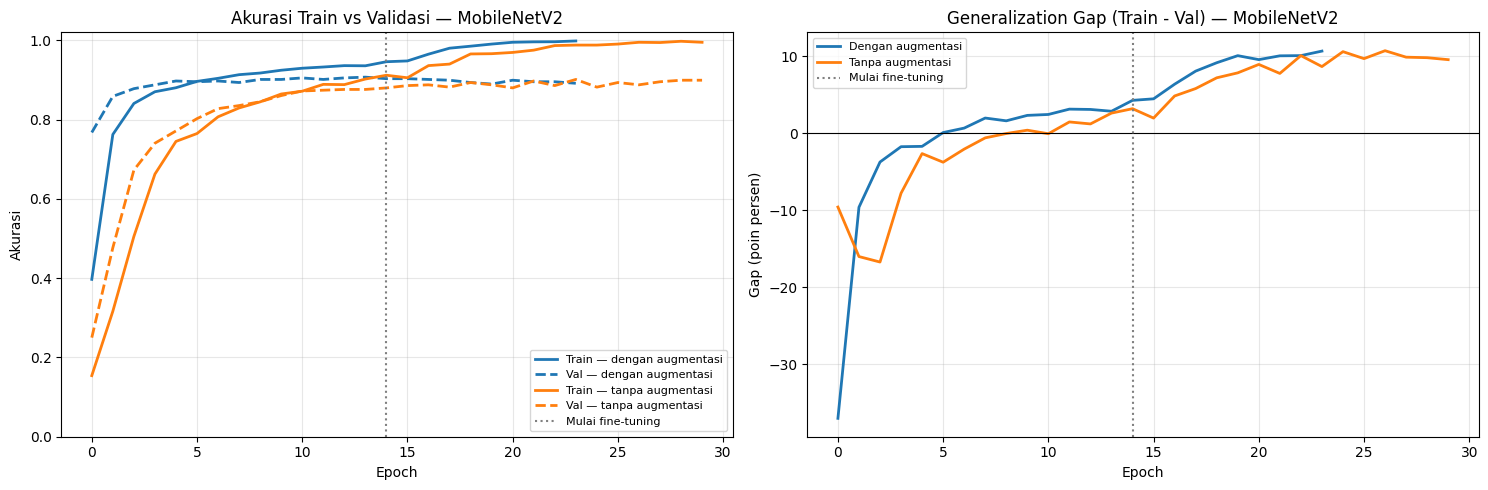

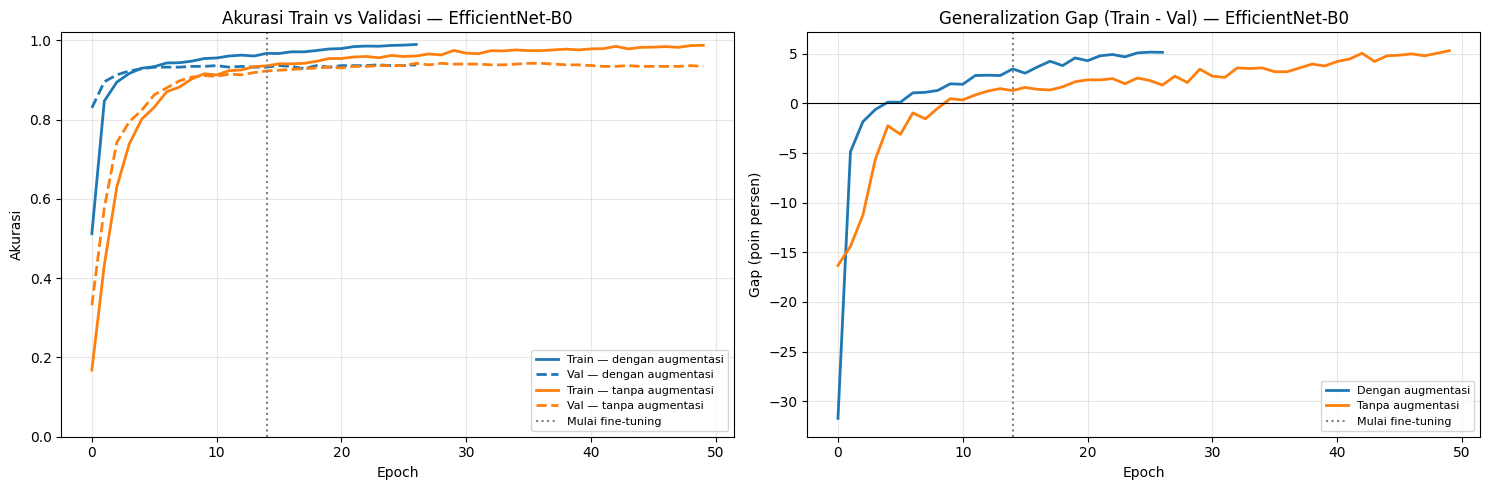

In [26]:
def plot_banding_augmentasi(h_aug, h_noaug, judul, fname):
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))
 
    # --- Panel kiri: kurva akurasi train vs val ---
    ax[0].plot(h_aug['accuracy'],       color='tab:blue',   lw=2,
               label='Train — dengan augmentasi')
    ax[0].plot(h_aug['val_accuracy'],   color='tab:blue',   lw=2, ls='--',
               label='Val — dengan augmentasi')
    ax[0].plot(h_noaug['accuracy'],     color='tab:orange', lw=2,
               label='Train — tanpa augmentasi')
    ax[0].plot(h_noaug['val_accuracy'], color='tab:orange', lw=2, ls='--',
               label='Val — tanpa augmentasi')
    ax[0].axvline(WARMUP - 1, color='gray', ls=':', label='Mulai fine-tuning')
    ax[0].set_title(f'Akurasi Train vs Validasi — {judul}')
    ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('Akurasi')
    ax[0].set_ylim(0, 1.02); ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)
 
    # --- Panel kanan: selisih (gap) train - val per epoch ---
    g_aug   = (np.array(h_aug['accuracy'])   - np.array(h_aug['val_accuracy']))   * 100
    g_noaug = (np.array(h_noaug['accuracy']) - np.array(h_noaug['val_accuracy'])) * 100
    ax[1].plot(g_aug,   color='tab:blue',   lw=2, label='Dengan augmentasi')
    ax[1].plot(g_noaug, color='tab:orange', lw=2, label='Tanpa augmentasi')
    ax[1].axhline(0, color='black', lw=.8)
    ax[1].axvline(WARMUP - 1, color='gray', ls=':', label='Mulai fine-tuning')
    ax[1].set_title(f'Generalization Gap (Train - Val) — {judul}')
    ax[1].set_xlabel('Epoch'); ax[1].set_ylabel('Gap (poin persen)')
    ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)
 
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/{fname}', dpi=150, bbox_inches='tight')
    plt.show()
 
plot_banding_augmentasi(hist_mob, hist_noaug_mob,
                        'MobileNetV2',     'gap_mobilenet.png')
plot_banding_augmentasi(hist_eff, hist_noaug_eff,
                        'EfficientNet-B0', 'gap_efficientnet.png')

In [27]:
def cek_manfaat_finetuning(hist, nama):
    vl = hist['val_loss']
    vl1, vl2 = vl[:WARMUP], vl[WARMUP:]
    b1, b2 = float(np.min(vl1)), (float(np.min(vl2)) if vl2 else float('nan'))
    print(f"\n=== {nama} ===")
    print(f"  val_loss terbaik Tahap 1 (warmup)     : {b1:.4f} (epoch {int(np.argmin(vl1))+1})")
    print(f"  val_loss terbaik Tahap 2 (fine-tuning): {b2:.4f} (epoch {int(np.argmin(vl2))+1+WARMUP})")
    print(f"  → Fine-tuning {'MEMBANTU' if b2 < b1 else 'TIDAK MEMBANTU'} "
          f"(selisih {b1-b2:+.4f})")
 
cek_manfaat_finetuning(hist_mob, 'MobileNetV2 + Augmentasi')
cek_manfaat_finetuning(hist_eff, 'EfficientNet-B0 + Augmentasi')


=== MobileNetV2 + Augmentasi ===
  val_loss terbaik Tahap 1 (warmup)     : 0.2939 (epoch 15)
  val_loss terbaik Tahap 2 (fine-tuning): 0.3006 (epoch 16)
  → Fine-tuning TIDAK MEMBANTU (selisih -0.0067)

=== EfficientNet-B0 + Augmentasi ===
  val_loss terbaik Tahap 1 (warmup)     : 0.1970 (epoch 15)
  val_loss terbaik Tahap 2 (fine-tuning): 0.1837 (epoch 19)
  → Fine-tuning MEMBANTU (selisih +0.0133)
